In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from dstapi import DstApi

%load_ext autoreload
%autoreload 2


ifor41 = DstApi("IFOR41")
ifor41.tablesummary(language='en')
ifor41.variable_levels('ULLIG', language='en')



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [ ]:
ifor41 = DstApi('IFOR41')
ifor41.tablesummary(language='en')


ifor41.variable_levels('KOMMUNEDK', language='en')  
ifor41.variable_levels('ULLIG', language='en')    #
ifor41.variable_levels('Tid', language='en')

params_gini = ifor41._define_base_params(language='en')
params_gini['variables'] = [
    {'code': 'KOMMUNEDK', 'values': ['000']},  
    {'code': 'ULLIG',  'values': ['70']},     
    {'code': 'Tid',    'values': ['*']},     
]

gini = ifor41.get_data(params=params_gini)
gini = gini.rename(columns={'INDHOLD': 'gini'})
gini['TID'] = gini['TID'].astype(int)
gini = gini[['TID', 'gini']].sort_values('TID').reset_index(drop=True)

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


In [ ]:


ifor32 = DstApi('IFOR32')
ifor32.tablesummary(language='en')

# Tjek variabelnavne og koder - ret til hvis dit tablesummary output afviger
ifor32.variable_levels('KOMMUNEDK', language='en')
ifor32.variable_levels('DECILGEN', language='en')
ifor32.variable_levels('Tid', language='en')

params_decile = ifor32._define_base_params(language='en')
params_decile['variables'] = [
    {'code': 'KOMMUNEDK', 'values': ['000']},   # Hele landet - tjek at '000' er den rigtige kode
    {'code': 'DECILGEN',  'values': ['*']},     # alle deciler
    {'code': 'Tid',       'values': ['*']},     # alle år
]

decile = ifor32.get_data(params=params_decile)
decile = decile.rename(columns={'INDHOLD': 'avg_income'})
decile['TID'] = decile['TID'].astype(int)

# --- VIGTIGT: tjek de faktiske labels, før du filtrerer ---
print(decile['DECILGEN'].unique())

# Match kun de 10 faktiske decil-kategorier - undgår evt. "I alt"/totalkategori
decile_labels = [f'{i}. decil' for i in range(1, 11)]   # ret teksten til hvad unique() faktisk viser
deciles_only = decile[decile['DECILGEN'].isin(decile_labels)].copy()

# Sanity check: skal give 10 rækker pr. år
n_per_year = deciles_only.groupby('TID').size()
assert n_per_year.eq(10).all(), n_per_year[n_per_year != 10]

# Udregn top-10-andel: ȳ10 / sum(ȳ1..ȳ10) for hvert år
decile_sum = deciles_only.groupby('TID')['avg_income'].sum().rename('sum_income')
decile_top = (
    deciles_only[deciles_only['DECILGEN'] == '10. decil']
    .set_index('TID')['avg_income']
    .rename('top10_avg')
)

top10 = pd.concat([decile_top, decile_sum], axis=1)
top10['top10_share'] = top10['top10_avg'] / top10['sum_income']
top10 = top10.reset_index()[['TID', 'top10_share']]


Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00
<ArrowStringArray>
[  'First decil',  'Second decil',   'Third decil',  'Fourth decil',
   'Fifth decil',   'Sixth decil', 'Seventh decil',   'Eigth decil',
   'Ninth decil',   'Tenth decil']
Length: 10, dtype: str


,TID,gini,top10_share


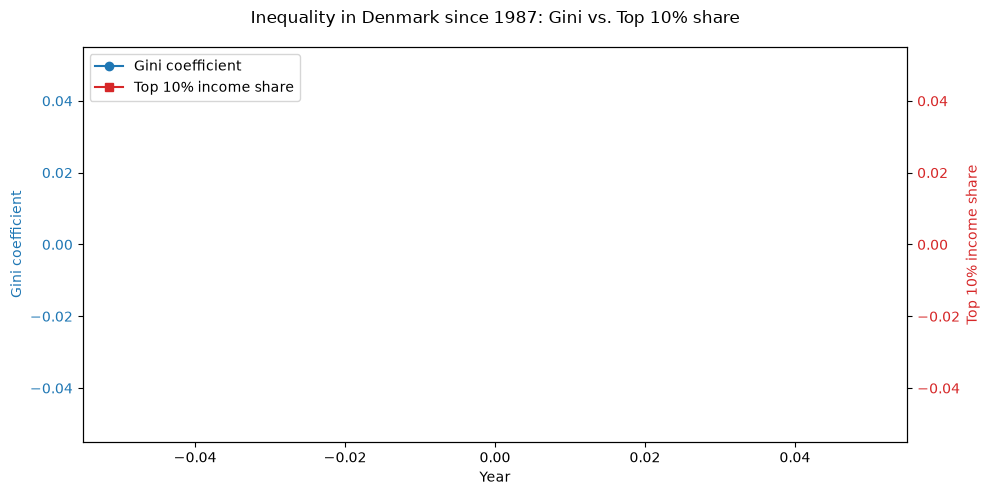

Correlation between Gini coefficient and top 10% income share: nan


In [10]:
# --- Trin 3: Merge, figur og korrelation ---

df = pd.merge(gini, top10, on='TID', how='inner', validate='1:1')
df = df[df['TID'] >= 1987].sort_values('TID').reset_index(drop=True)

display(df)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df['TID'], df['gini'], color='tab:blue', marker='o', label='Gini coefficient')
ax1.set_xlabel('Year')
ax1.set_ylabel('Gini coefficient', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(df['TID'], df['top10_share'], color='tab:red', marker='s', label='Top 10% income share')
ax2.set_ylabel('Top 10% income share', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.suptitle('Inequality in Denmark since 1987: Gini vs. Top 10% share')

# Fælles legend for begge akser
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()

# Korrelation mellem de to mål
corr = df['gini'].corr(df['top10_share'])
print(f'Correlation between Gini coefficient and top 10% income share: {corr:.3f}')

NameError: name 'array' is not defined

# Opgave 2
# Opgave 2.1

In [14]:
"""
Life-cycle simulation: education -> labor market -> human capital -> income.

Structure:
  - Loop over AGE (18 to 65), not over individuals. Everything inside the
    loop is a vectorized numpy operation on all N individuals at once.
  - Each individual carries a small set of "state" arrays that get updated
    every period: in_education, employed, human_capital, years_in_edu.
"""

import numpy as np
import pandas as pd


def simulate(seed=2024, N=50_000):
    rng = np.random.default_rng(seed)

    # ---------------------------------------------------------------
    # Parameters
    # ---------------------------------------------------------------
    ages = np.arange(18, 66)          # 18, 19, ..., 65  -> T periods
    T = len(ages)

    pe        = np.array([0.40, 0.35, 0.25])          # education probabilities
    Se        = np.array([1, 3, 5])                   # years of education
    h0        = np.array([1.00, 1.20, 1.55])           # initial human capital
    delta_e   = np.array([0.010, 0.020, 0.030])         # HC growth while employed

    delta      = 0.06     # HC depreciation while unemployed
    sigma_psi  = 0.10     # std of log human-capital shock
    lam        = 0.60     # job-finding probability
    sigma      = 0.05     # job-separation probability
    y_SU       = 0.45     # student grant
    rho        = 0.60     # replacement rate
    y_floor    = 0.35     # benefit floor

    # ---------------------------------------------------------------
    # 1. Draw education at age 18 (once, per individual)
    # ---------------------------------------------------------------
    edu = rng.choice(3, size=N, p=pe)          # 0=short, 1=medium, 2=long
    Se_i = Se[edu]
    delta_e_i = delta_e[edu]
    age_enters_labor = 18 + Se_i               # age at which each person finishes school

    # ---------------------------------------------------------------
    # State that evolves over time
    # ---------------------------------------------------------------
    h = h0[edu].astype(float)                  # current human capital
    employed = np.zeros(N, dtype=bool)          # only meaningful once in labor market

    # Storage: one column per age
    income_panel = np.full((N, T), np.nan)
    hc_panel = np.full((N, T), np.nan)
    state_panel = np.empty((N, T), dtype=object)   # 'education' / 'unemployed' / 'employed'

    # ---------------------------------------------------------------
    # 2. Loop over age
    # ---------------------------------------------------------------
    for t, age in enumerate(ages):

        in_education = age < age_enters_labor
        in_labor = ~in_education
        entering_now = in_labor & (age_enters_labor == age)   # first labor-market period
        already_in_labor = in_labor & ~entering_now

        # -- employment transitions (Markov chain) for those already in labor market --
        u = rng.random(N)
        becomes_employed = already_in_labor & (~employed) & (u < lam)
        becomes_unemployed = already_in_labor & employed & (u < sigma)
        employed[becomes_employed] = True
        employed[becomes_unemployed] = False

        # everyone entering the labor market for the first time starts out unemployed
        employed[entering_now] = False

        # -- income this period --
        income_t = np.full(N, np.nan)
        income_t[in_education] = y_SU

        wage = h  # assumption: wage = current human capital
        income_t[in_labor & employed] = wage[in_labor & employed]
        benefit = np.maximum(rho * wage, y_floor)
        income_t[in_labor & ~employed] = benefit[in_labor & ~employed]

        income_panel[:, t] = income_t
        hc_panel[:, t] = h

        state_panel[in_education, t] = "education"
        state_panel[in_labor & employed, t] = "employed"
        state_panel[in_labor & ~employed, t] = "unemployed"

        # -- human capital evolution to NEXT period (unchanged while in education) --
        psi = rng.lognormal(-0.5 * sigma_psi**2, sigma_psi, size=N)
        h_next = h.copy()
        mask_emp = in_labor & employed
        mask_unemp = in_labor & ~employed
        h_next[mask_emp] = h[mask_emp] * (1 + delta_e_i[mask_emp]) * psi[mask_emp]
        h_next[mask_unemp] = h[mask_unemp] * (1 - delta) * psi[mask_unemp]
        h = h_next  # education-state individuals keep h unchanged

    return {
        "ages": ages,
        "edu": edu,
        "income": income_panel,
        "human_capital": hc_panel,
        "state": state_panel,
    }


if __name__ == "__main__":
    out = simulate()

    # sanity check: mean of the lognormal shock should be ~1
    rng = np.random.default_rng(0)
    psi_check = rng.lognormal(-0.5 * 0.10**2, 0.10, size=1_000_000)
    print("mean(psi) check:", psi_check.mean())  # should be close to 1.0

    # quick summary: average income by age
    df = pd.DataFrame(out["income"], columns=out["ages"])
    print(df.mean(axis=0).round(3))

mean(psi) check: 1.0001063731975506
18    0.450
19    0.510
20    0.585
21    0.707
22    0.798
23    0.951
24    1.041
25    1.080
26    1.104
27    1.122
28    1.138
29    1.154
30    1.172
31    1.188
32    1.206
33    1.224
34    1.239
35    1.258
36    1.276
37    1.294
38    1.313
39    1.331
40    1.350
41    1.370
42    1.391
43    1.411
44    1.432
45    1.453
46    1.476
47    1.499
48    1.524
49    1.546
50    1.572
51    1.596
52    1.621
53    1.646
54    1.670
55    1.697
56    1.721
57    1.748
58    1.776
59    1.804
60    1.831
61    1.862
62    1.893
63    1.920
64    1.952
65    1.983
dtype: float64


=== Validation ===
Education shares (target [0.4  0.35 0.25]):
  simulated: [0.3973 0.3561 0.2466]

Steady-state unemployment rate (target sigma/(sigma+lambda) = 0.0769):
  simulated (ages >= 40): 0.0768

Saved: income_lifecycle.png, income_histograms.png

=== Distribution shape by age ===
Age 25: mean=1.080, sd=0.328, skew=0.324, p10=0.676, p50=1.052, p90=1.528
Age 35: mean=1.258, sd=0.628, skew=1.377, p10=0.591, p50=1.132, p90=2.088
Age 45: mean=1.453, sd=0.969, skew=2.095, p10=0.537, p50=1.206, p90=2.646
Age 60: mean=1.831, sd=1.680, skew=3.139, p10=0.482, p50=1.333, p90=3.732


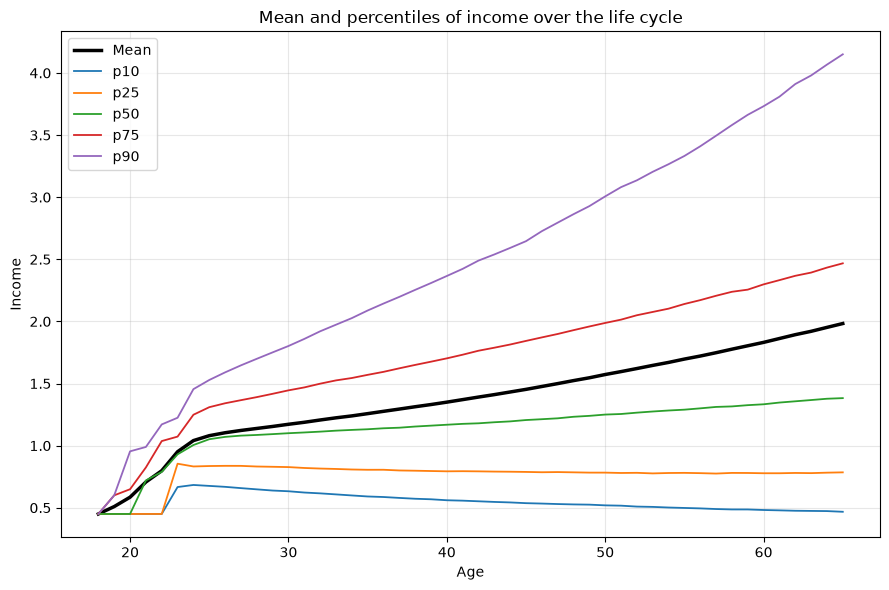

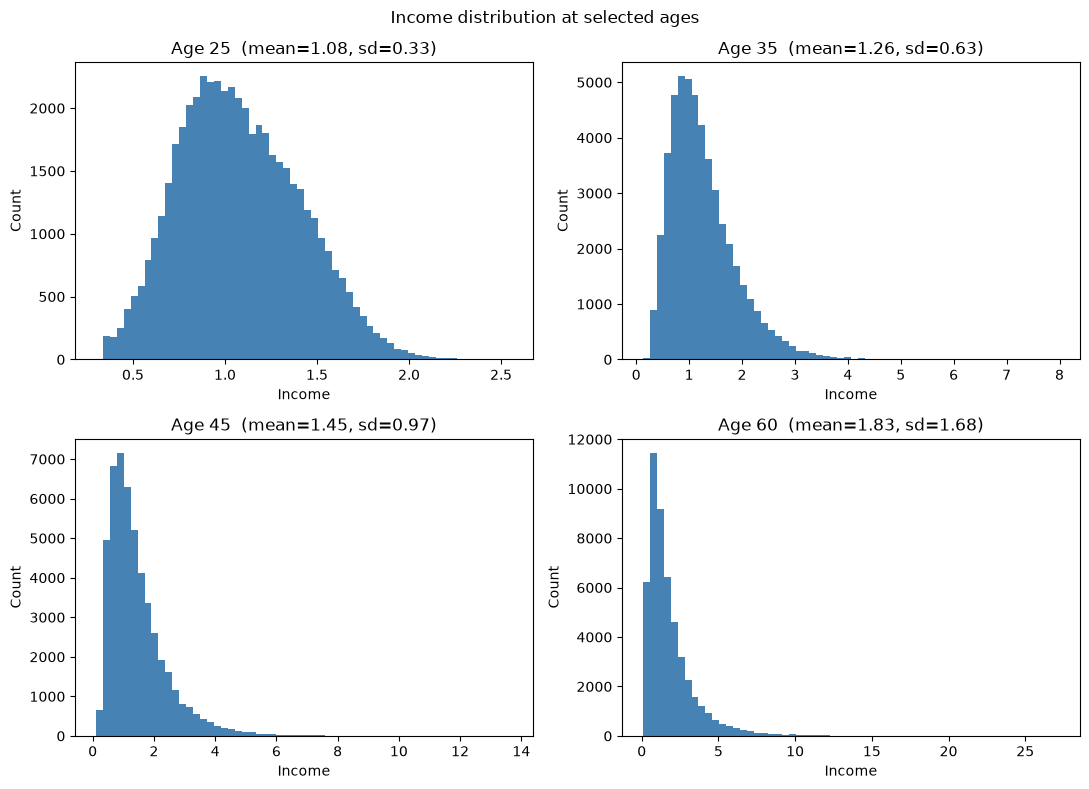

In [16]:
"""
2.2 Simulate the income distribution

1. Validate the simulation (education shares, steady-state unemployment rate)
2. Plot mean + percentiles of income over the life cycle
3. Plot income histograms at ages 25, 35, 45, 60
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


out = simulate(seed=2024, N=50_000)
ages = out["ages"]
edu = out["edu"]
income = out["income"]          # shape (N, T)
state = out["state"]            # shape (N, T)

lam = 0.60
sigma = 0.05
pe = np.array([0.40, 0.35, 0.25])

# ---------------------------------------------------------------
# 1. Validation checks
# ---------------------------------------------------------------
print("=== Validation ===")

edu_shares = np.bincount(edu, minlength=3) / len(edu)
print(f"Education shares (target {pe}):")
print(f"  simulated: {edu_shares.round(4)}")

# Steady-state unemployment rate among people IN the labor market,
# using the later ages where the age-composition of the labor market
# has stabilized (e.g. from age 40 onward).
ss_target = sigma / (sigma + lam)
late_ages_mask = ages >= 40
labor_market = (state[:, late_ages_mask] == "employed") | (state[:, late_ages_mask] == "unemployed")
unemployed_mask = state[:, late_ages_mask] == "unemployed"
sim_unemp_rate = unemployed_mask.sum() / labor_market.sum()

print(f"\nSteady-state unemployment rate (target sigma/(sigma+lambda) = {ss_target:.4f}):")
print(f"  simulated (ages >= 40): {sim_unemp_rate:.4f}")

# also show it age-by-age to see it converge
unemp_by_age = []
for t, age in enumerate(ages):
    lm = (state[:, t] == "employed") | (state[:, t] == "unemployed")
    if lm.sum() > 0:
        unemp_by_age.append(((state[:, t] == "unemployed").sum()) / lm.sum())
    else:
        unemp_by_age.append(np.nan)
unemp_by_age = pd.Series(unemp_by_age, index=ages)

# ---------------------------------------------------------------
# 2. Mean and percentiles of income over the life cycle
# ---------------------------------------------------------------
percentiles = [10, 25, 50, 75, 90]
income_df = pd.DataFrame(income, columns=ages)

mean_income = income_df.mean(axis=0)
pct_income = income_df.quantile([p / 100 for p in percentiles], axis=0).T
pct_income.columns = [f"p{p}" for p in percentiles]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(ages, mean_income, color="black", linewidth=2.5, label="Mean")
for p in percentiles:
    ax.plot(ages, pct_income[f"p{p}"], linewidth=1.3, label=f"p{p}")
ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_title("Mean and percentiles of income over the life cycle")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("income_lifecycle.png", dpi=150)

# ---------------------------------------------------------------
# 3. Histograms at ages 25, 35, 45, 60
# ---------------------------------------------------------------
hist_ages = [25, 35, 45, 60]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, age in zip(axes.flat, hist_ages):
    col = income_df[age]
    ax.hist(col, bins=60, color="steelblue", edgecolor="none")
    ax.set_title(f"Age {age}  (mean={col.mean():.2f}, sd={col.std():.2f})")
    ax.set_xlabel("Income")
    ax.set_ylabel("Count")
fig.suptitle("Income distribution at selected ages")
fig.tight_layout()
fig.savefig("income_histograms.png", dpi=150)

print("\nSaved: income_lifecycle.png, income_histograms.png")

# print some distributional stats to describe the shape changes
print("\n=== Distribution shape by age ===")
for age in hist_ages:
    col = income_df[age]
    print(f"Age {age}: mean={col.mean():.3f}, sd={col.std():.3f}, "
          f"skew={col.skew():.3f}, p10={col.quantile(.1):.3f}, "
          f"p50={col.quantile(.5):.3f}, p90={col.quantile(.9):.3f}")

# Opgave 2.3

=== Validating gini() against closed-form cases ===

Uniform[0,1]:      simulated Gini = 0.33330   (target = 1/3 = 0.33333)
Lognormal(s=0.25):   simulated Gini = 0.14028   (target = 0.14032)
Lognormal(s=0.5):   simulated Gini = 0.27623   (target = 0.27633)
Lognormal(s=1.0):   simulated Gini = 0.52051   (target = 0.52050)

Pooled Gini (all individuals, all ages together): 0.3628

Gini by age (selected):
  age 18: -0.0000
  age 25: 0.1724
  age 35: 0.2661
  age 45: 0.3364
  age 55: 0.3973
  age 65: 0.4485

Mean of within-age Gini (age >= 24, i.e. everyone in labor market): 0.3243
Pooled Gini (all ages together): 0.3628

Saved: lorenz_curve.png, gini_by_age.png


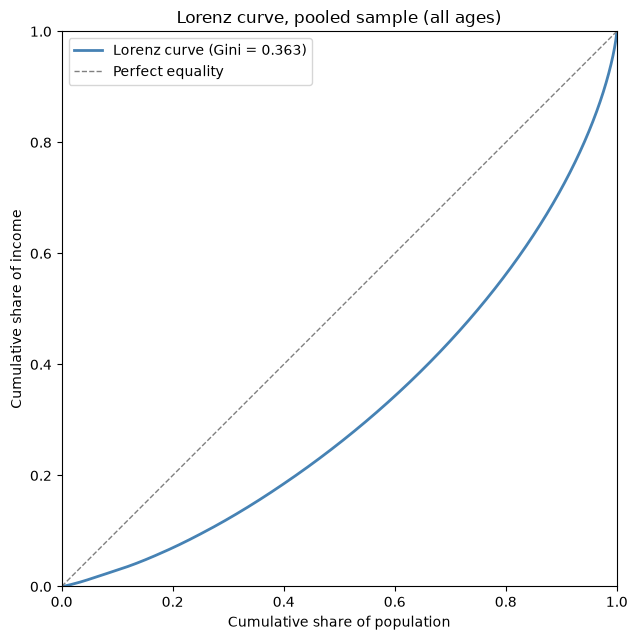

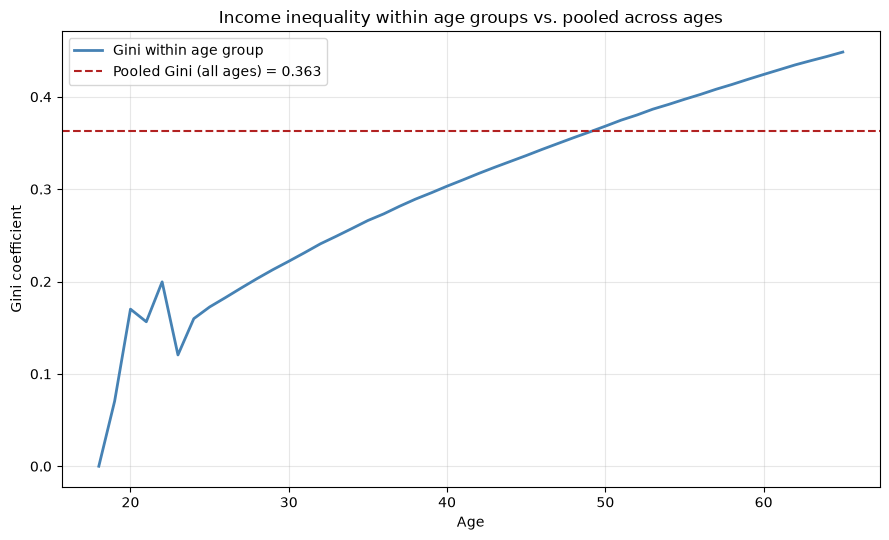

In [17]:
"""
2.3 Compute the Gini coefficient

- own gini() function
- validated against two closed-form cases:
    uniform[0,1]      -> Gini = 1/3
    lognormal(s)      -> Gini = 2*Phi(s/sqrt(2)) - 1
- Gini + Lorenz curve for the pooled simulated sample
- Gini by age, compared to the pooled Gini
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def gini(x):
    """
    Gini coefficient of a 1-D array of non-negative incomes.

    Uses the standard rank-based formula:
        G = [2 * sum_{i=1}^n i * x_(i)  -  (n+1) * sum(x)] / (n * sum(x))
    where x_(i) is x sorted in ascending order and i = 1, ..., n.
    """
    x = np.asarray(x, dtype=float)
    x = np.sort(x)
    n = x.size
    if n == 0 or x.sum() == 0:
        raise ValueError("gini() needs a non-empty array with positive total income")
    ranks = np.arange(1, n + 1)
    return (2 * np.sum(ranks * x) - (n + 1) * x.sum()) / (n * x.sum())


def lorenz_curve(x):
    """Return (cumulative population share, cumulative income share), both starting at (0,0)."""
    x = np.sort(np.asarray(x, dtype=float))
    n = x.size
    cum_income = np.cumsum(x) / x.sum()
    cum_pop = np.arange(1, n + 1) / n
    # prepend the (0,0) point
    return np.concatenate([[0], cum_pop]), np.concatenate([[0], cum_income])


# ---------------------------------------------------------------
# Validation against known closed-form cases
# ---------------------------------------------------------------
print("=== Validating gini() against closed-form cases ===\n")

rng = np.random.default_rng(42)

# 1. Uniform[0,1] -> Gini = 1/3
u = rng.uniform(0, 1, size=2_000_000)
g_u = gini(u)
print(f"Uniform[0,1]:      simulated Gini = {g_u:.5f}   (target = 1/3 = {1/3:.5f})")

# 2. Lognormal with std of log = s -> Gini = 2*Phi(s/sqrt(2)) - 1
for s in [0.25, 0.5, 1.0]:
    ln = rng.lognormal(mean=0, sigma=s, size=2_000_000)
    g_ln = gini(ln)
    target = 2 * norm.cdf(s / np.sqrt(2)) - 1
    print(f"Lognormal(s={s}):   simulated Gini = {g_ln:.5f}   (target = {target:.5f})")

print()

# ---------------------------------------------------------------
# 1. Gini + Lorenz curve for the pooled sample
# ---------------------------------------------------------------
out = simulate(seed=2024, N=50_000)
ages = out["ages"]
income = out["income"]  # (N, T)

pooled = income.flatten()
gini_pooled = gini(pooled)
print(f"Pooled Gini (all individuals, all ages together): {gini_pooled:.4f}")

pop_share, income_share = lorenz_curve(pooled)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(pop_share, income_share, color="steelblue", linewidth=2,
        label=f"Lorenz curve (Gini = {gini_pooled:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Perfect equality")
ax.set_xlabel("Cumulative share of population")
ax.set_ylabel("Cumulative share of income")
ax.set_title("Lorenz curve, pooled sample (all ages)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig("lorenz_curve.png", dpi=150)

# ---------------------------------------------------------------
# 2. Gini by age vs pooled
# ---------------------------------------------------------------
gini_by_age = np.array([gini(income[:, t]) for t in range(len(ages))])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(ages, gini_by_age, color="steelblue", linewidth=2, label="Gini within age group")
ax.axhline(gini_pooled, color="firebrick", linestyle="--", linewidth=1.5,
           label=f"Pooled Gini (all ages) = {gini_pooled:.3f}")
ax.set_xlabel("Age")
ax.set_ylabel("Gini coefficient")
ax.set_title("Income inequality within age groups vs. pooled across ages")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("gini_by_age.png", dpi=150)

print("\nGini by age (selected):")
for age in [18, 25, 35, 45, 55, 65]:
    idx = age - 18
    print(f"  age {age}: {gini_by_age[idx]:.4f}")

print(f"\nMean of within-age Gini (age >= 24, i.e. everyone in labor market): "
      f"{gini_by_age[6:].mean():.4f}")
print(f"Pooled Gini (all ages together): {gini_pooled:.4f}")

print("\nSaved: lorenz_curve.png, gini_by_age.png")

# 